In [2]:
import cite
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import fetch_openml

In [3]:
X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)

X matrix shape:  (70000, 784)
amount of unique y marks:  10


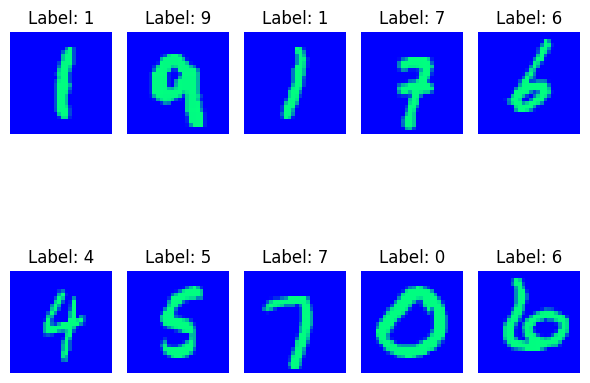

In [9]:
print("X matrix shape: ", X.shape)
print("amount of unique y marks: ", len(np.unique(y)))
plt.figure(figsize=(6, 6))
rand_index = np.random.choice(X.shape[0], 10, replace=False)
for i, ind in enumerate(rand_index):
    plt.subplot(2, 5, i + 1)
    image = X[ind].reshape(28, 28)
    plt.imshow(image, cmap='winter')
    plt.title(f"Label: {y[ind]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [5]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X)
for i, ratio in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i}: {ratio}")

PC0: 0.09746115922494752
PC1: 0.07155444586878709
PC2: 0.06149530980723029


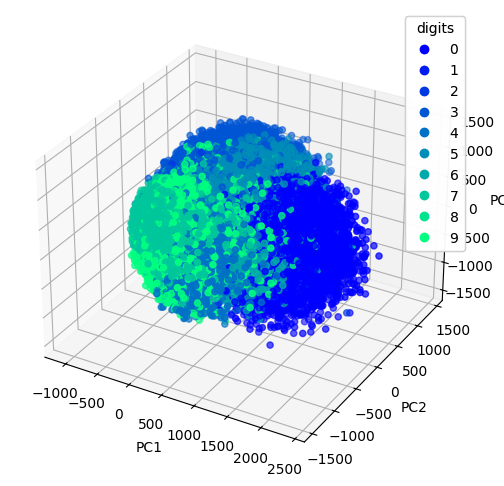

In [6]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection="3d")
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2],
                     c=y.astype(int), cmap=plt.cm.winter)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
legend = ax.legend(*scatter.legend_elements(), title="digits")
ax.add_artist(legend)
plt.show()


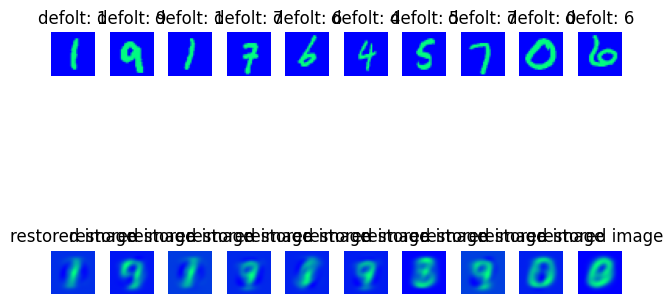

In [10]:
X_restored = pca.inverse_transform(X_pca)
plt.figure(figsize=(6, 6))
indices = np.random.choice(len(X), 10, replace=False)
for i, ind in enumerate(rand_index):
    ax = plt.subplot(2, 10, i + 1)
    plt.imshow(X[ind].reshape(28, 28), cmap='winter')
    plt.title(f"defolt: {y[ind]}")
    plt.axis('off')

    ax = plt.subplot(2, 10, i + 11)
    plt.imshow(X_restored[ind].reshape(28, 28), cmap='winter')
    plt.title("restored image")
    plt.axis('off')
plt.tight_layout()
plt.show()

k=  1: MSE = 3948.58, dispersion = 9.75%
k=  5: MSE = 2916.20, dispersion = 33.34%
k= 10: MSE = 2234.86, dispersion = 48.92%
k= 15: MSE = 1835.48, dispersion = 58.05%
k= 30: MSE = 1174.10, dispersion = 73.16%
k= 50: MSE = 763.79, dispersion = 82.54%
k=100: MSE = 372.02, dispersion = 91.50%
k=250: MSE = 95.51, dispersion = 97.82%


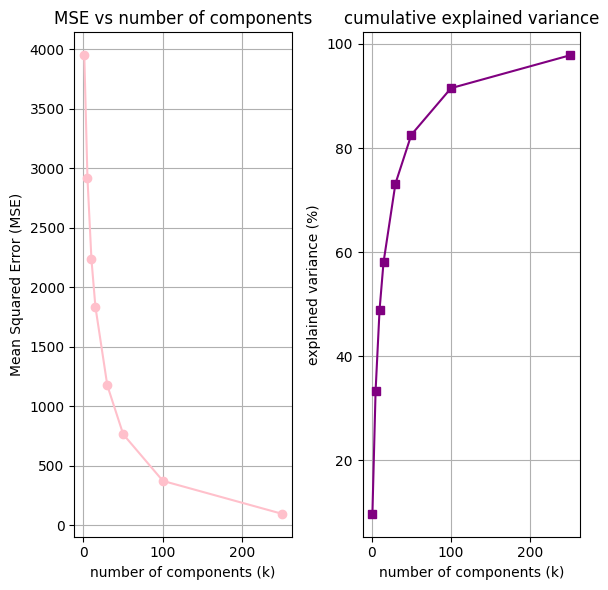

In [15]:
from sklearn.metrics import mean_squared_error
components = [1, 5, 10, 15, 30, 50, 100, 250]
values = []
sums = []
for c in components:
    pca_c = PCA(n_components=c)
    X_pca = pca_c.fit_transform(X)
    X_rec_k = pca_c.inverse_transform(X_pca)

    mse = mean_squared_error(X, X_rec_k)
    values.append(mse)

    var_sum = np.sum(pca_c.explained_variance_ratio_) * 100
    sums.append(var_sum)
    print(f"k={c:3}: MSE = {mse:.2f}, dispersion = {var_sum:.2f}%")
plt.figure(figsize=(6, 6))
plt.subplot(1, 2, 1)
plt.plot(components, values, marker='o', color='pink')
plt.title("MSE vs number of components")
plt.xlabel("number of components (k)")
plt.ylabel("Mean Squared Error (MSE)")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(components, sums, marker='s', color='purple')
plt.title("cumulative explained variance")
plt.xlabel("number of components (k)")
plt.ylabel("explained variance (%)")
plt.grid(True)

plt.tight_layout()
plt.show()